# MZMine

Documentation:  https://mzmine.github.io/mzmine_documentation/index.html

publication:   https://www.nature.com/articles/s41587-023-01690-2

if you prefer video guide, they have one for generic non-targeted LCMS/MS:  https://youtu.be/UnqVtZngzl0?si=AN94t130vgQSNIOq

Note that the software is constantly updated. you may choose to update it whenever a new version is released

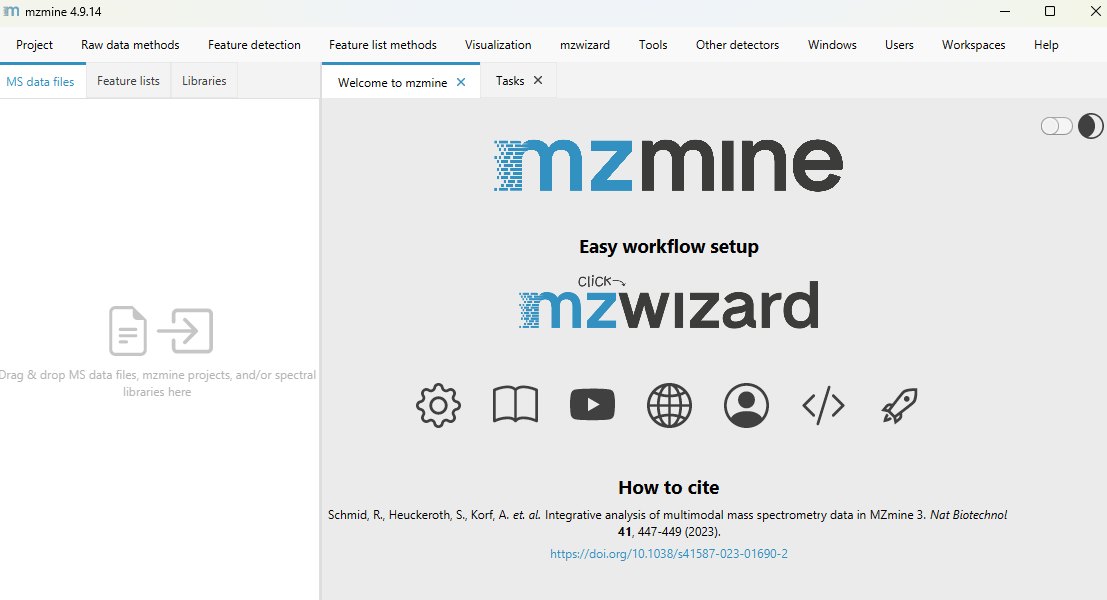



## you do need an account with them to use the software !

for student, this is free to use and they give you an one-year free license (simply renew it if expired. no cost!)

<br>
<br>
<br>
<br>





we can simply use the `mzwizard` for setup either with the `mzwizard` on the top or click the middle of the starting window

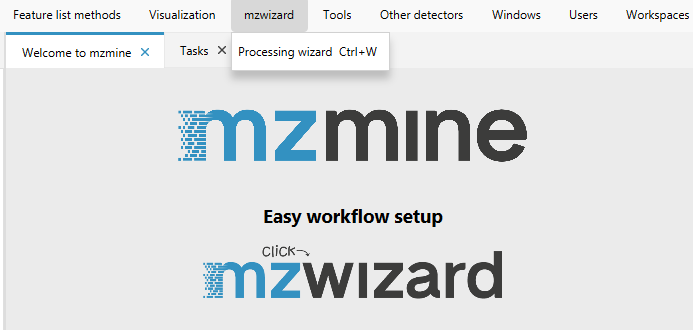


they have a page in the documentation that introduce pretty much everything: https://mzmine.github.io/mzmine_documentation/wizard.html

But... to save you some time, ill just show you how i usually process my data...


#### Note, everything in the screenshot is for demostration purpose, you should check each individual descriptrion (if listed) for the setting!

## 1. Data


Frist thing first, select the data

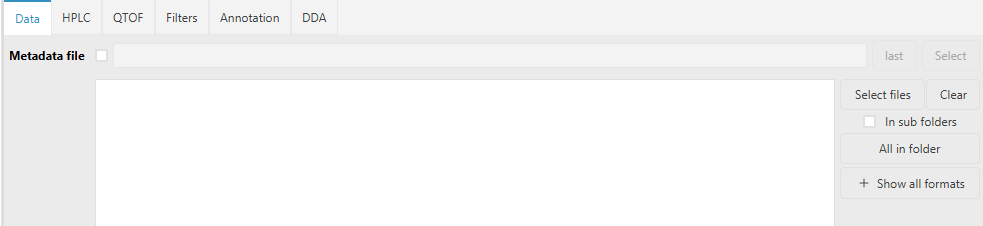

MZMine do accept `.raw` file directly from Obitrap since few versions ago. no need to convert to mzml (although on the backend they're doing about the same thing anyway)

after selection, everything will show up in the middle space 

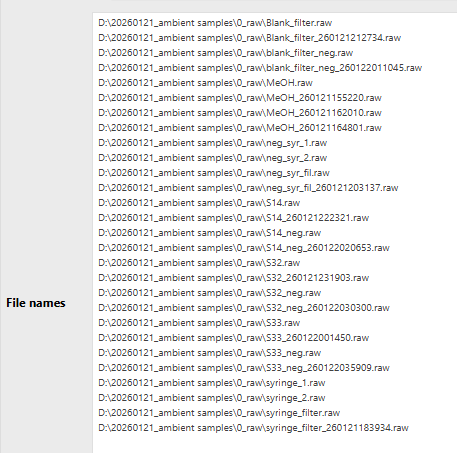

## 2. selecting instrument setup 

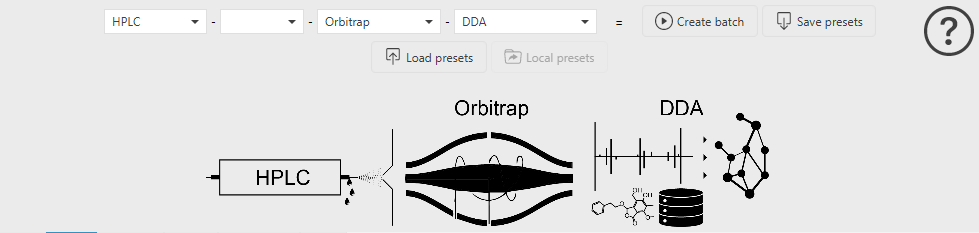


different instrument may have slightly different setting on the backend. 

most of the time, we're using normal HPLC system (with pressure around 500 bar). 

it does have an option in the middle that for other instrumentation like TIMS-TOF, not us anywat. leave it blank 

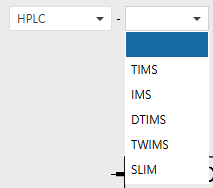

and of course we're mostly using orbitrap but select whichever you're using 

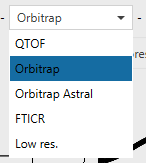

by default they think everything should be MS 2. if you dont, leave it as DDA

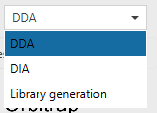



## 3. HPLC setting

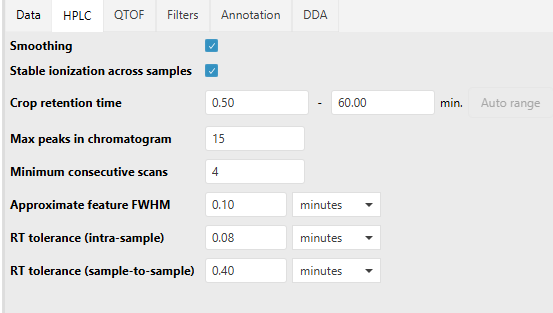


note, this is the default setting.

in generall, you can fine tune this based on your sample (for example, too much stuff in biomass burning) and LC condition (5 min vs 30 min gradient). 



Here are a few things i would change: 


### Maximum peak in chromatograms (default 15)

In theory, this will will affect how many data points will be useful when resolving features. there's no good number for this. may increase if sample is complex
<br>

### Minimum consecutive scans (default 4)

this means: how many continuous data point for the program to consider the signal as real peak 

if your data is noisy and lots of small peak, you may set this to 3 (minumum to have a peak shape...)

<br>

### Approximate feature FWHM (default 0.1 min)

The estimated average FWHM for peak detection.

Too low = may cut large peaks into multiple

Too high = may merge nearby peaks

This is depending on the LC itself (i.e., UPLC usually has narrower peaks and thus can be a few to around 12 seconds).
-> Need to check the raw data before setting this number!

<br>

### RT tolerance (intra-sample) (default 0.08 min)

This affects how the program to consider adducst and isotopes of molecules (in theory, they should coelute pretty much perfectly)

<br>

### RT tolerance (sample-to-sample)

this affects the alignment betwen samples. usually, if you're LC is stable enough, the RT different shouldnt be too much (like more than 5 seconds)

**You may change this to a smaller number if you know all your data aligns pretty well on TIC**

<br>


## 4. Orbitrap setting 

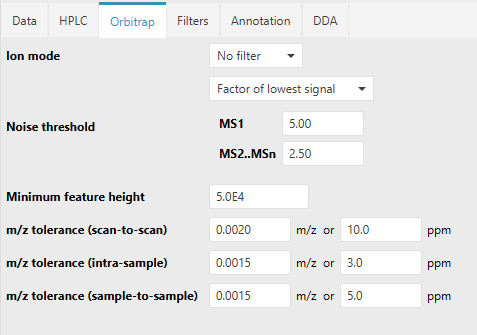

### ion mode

usually not important if you selected your data and they are run without polarity switching. filter if needed


### Noise threshold (MS1/MS2)

usually Factor of lowest signal is fine. 

you may use `absolute intensity` if you know the noise is low or those were filtered already before proessing

### Minimum feature height


__This can be important!!__ 

anything below this threshold will not be considered in your data after processing. in general, insturment can record peak with intensity as low as few hundreds while this could likely be noise. the software will still try to do everything if you try (i.e., youll still see the m/z value and formula if theres a match). it is generally connsidered to use __1E3__ and filter after in your own processing step. 

you should inspect your raw data before setting this value unless you know your insturment.

### Scan-to-scan m/z tolerance, Feature-to-feature m/z tolerance, Sample-to-sample m/z tolerance

similar in LC setting, we have within samples (scan to scan of same feature, or feature to feature) and sample to sample alignment and thus m/z tolerance is important.

You should know you're instrument's mass error when running the sample by inspecting commonly found background or standards. 

for orbitrap, we should expect a mass error lower than **5 ppm**. assuming the instrument is stable, this error window should be the same for all sample and all scans. 

change if needed (especially lower it if you know the data quality is good !)


<br>


## 5. Filters

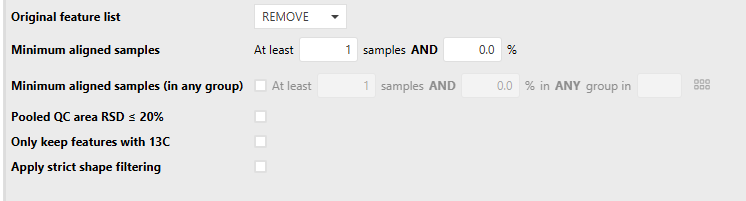

not much to change here.. may skip unless you want specific things (usually pretty strick filtering)




## 6. Annotation

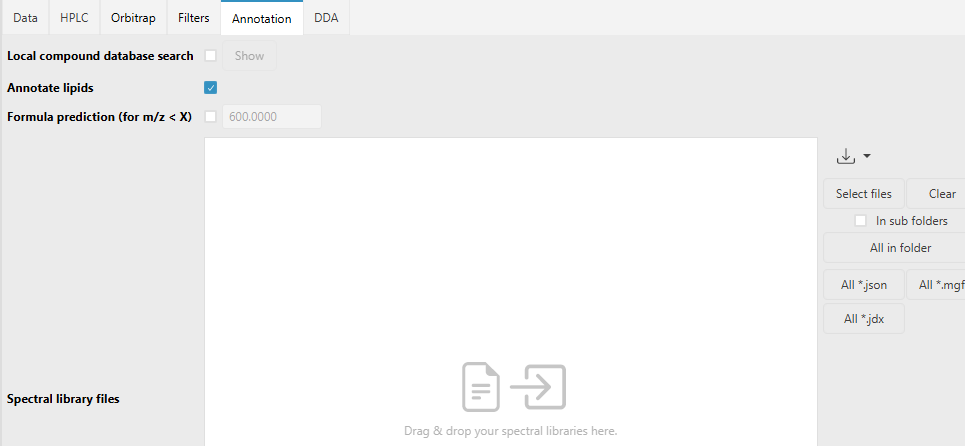

the only thing i would do is **uncheck** the `Annotate lipids` since it wont give you anything but add extra step

## 7. DDA 

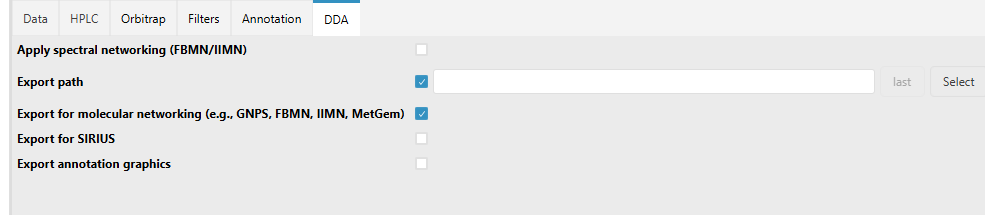

We may or may not have MS2 or DDA in the LCMS method. but `Export path` is useful since you only need to input there once and everything will be save in the path you choosed.





## 8. Create Batch

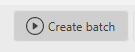

This is the detailed steps the program is doing.

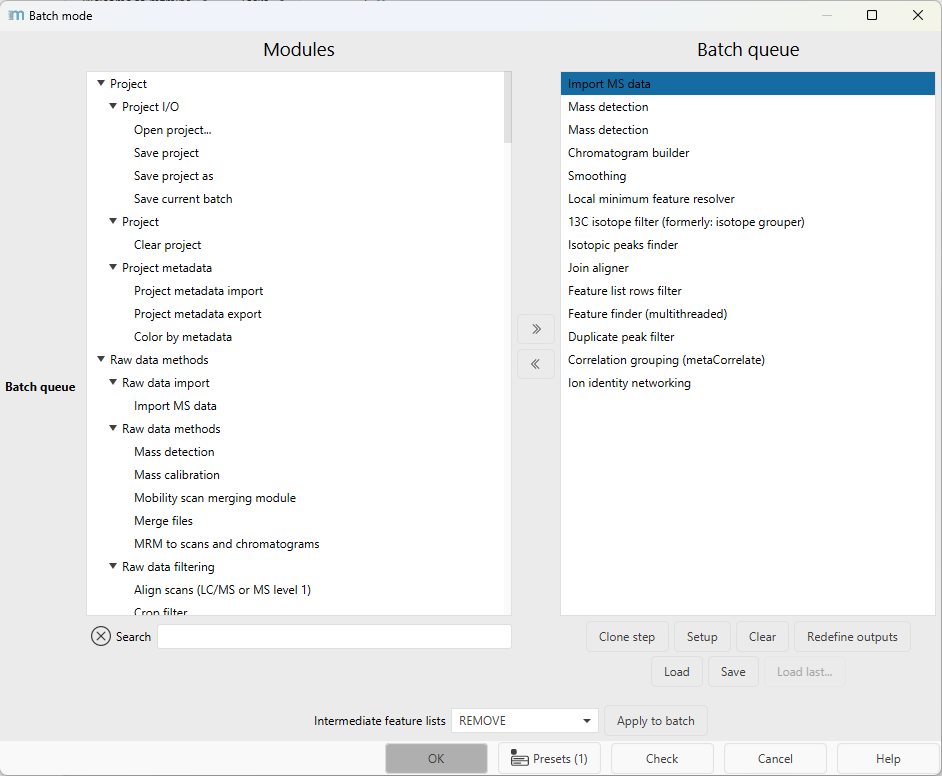




the left side shows all the modules that are available. you can click it and usee the `>>` bottom to add it to the left, which is the steps you're going to use

for each module, you have double click the name of it to see the setting of it! 



**what you may want to add:**


### Export to CSV

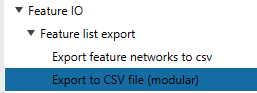

I like to have csv files to see what happened... 

note that you will want this to be after you have done everything (like formula prediction and others). you can drag the item down to reorder them.


### formula prediction
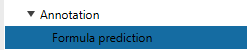

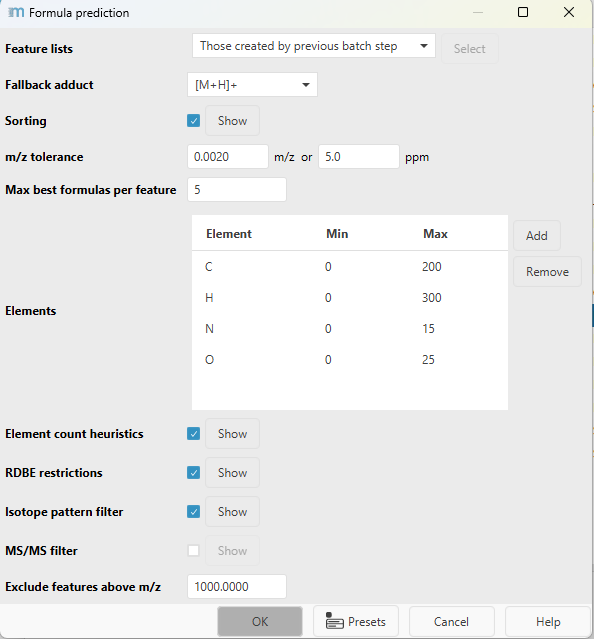


if formula is what you may use, this is handy to have 

note that for us it is reasonable to __set the min C and H to 1__. you may open each `show` bottom to see what filters are included, but usually it's fine to use them all. 

if you have somehting like Sulfur or other elements that may interfere the combination, you should use `isotope pattern filter`. however, in my experience with either this function and my own data, the pattern can be off in complex data. it wasnt really clear how they handle it in MZMine but always double check after

some exception:

- nitrogen rule can be weird if the mass is too large
- other elements (e.g., halogens) that may make the DBE or other calculation weird 





### save project and save batch

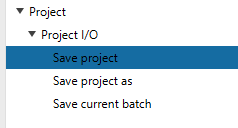

this will increase the time and memory use on the saving path which the program will save everything it had. 

saving the project can help you run individual module if need to rerun it in the future. however, this will be slow and the file will be huge

use if needed only. if you only have a few samples, no need to save as it should be processed very quickly

